In [651]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import numpy as np
class ASRPREP:
    def __init__(self):
        self.portfolio = pd.DataFrame(columns=['Ticker', 'Sector', 'Asset Class', 'Quantity', 'Purchase Price'])
        self.data = {}
    def add_stock(self, ticker, sector, asset_class, quantity, purchase_price):
        new_entry = {
            'Ticker': ticker,
            'Sector': sector,
            'Asset Class': asset_class,
            'Quantity': quantity,
            'Purchase Price': purchase_price}
        self.portfolio = pd.concat([self.portfolio, pd.DataFrame([new_entry])],ignore_index=True)
    def download_historical_data_portfolio(self,start,end=datetime.datetime.today().strftime('%Y-%m-%d')):
        tickers=self.portfolio['Ticker']
        for ticker in tickers: 
            self.data[ticker] = yf.download(ticker,start=start,end=end)
    def plot_historical_stock_price(self, tickers=None,individual_graph=False):
        if type(tickers)==str:
            tickers=[tickers]
        %matplotlib inline
        plt.figure(figsize=(12,4))
        close_list=pd.DataFrame()
        if individual_graph is True:
            if tickers is None or len(tickers)==0:
                for ticker in self.data:
                    close=self.data[ticker]['Close']
                    close.plot(label=ticker)
                    plt.title('Historical Closing Prices')
                    plt.xlabel("Date")
                    plt.ylabel("Stock Price[USD]")
                    plt.legend()
                    plt.grid(True)
                    plt.tight_layout()
                    plt.show()
            else:
                for ticker in tickers:
                    close=self.data[ticker]["Close"]
                    close.plot()
                    plt.title('Historical Closing Prices')
                    plt.xlabel("Date")
                    plt.ylabel("Stock Price[USD]")
                    plt.legend()
                    plt.grid(True)
                    plt.tight_layout()
                    plt.show()                 
        if tickers is None or len(tickers)==0:
            for ticker in self.data:
                close=self.data[ticker]['Close']
                close_list=pd.concat([close_list,close],axis=1)
        else:
            for ticker in tickers:
                close=self.data[ticker]["Close"]
                close_list=pd.concat([close_list,close],axis=1)
        close_list.plot(label=ticker)
        plt.title('Historical Closing Prices')
        plt.xlabel("Date")
        plt.ylabel("Stock Price[USD]")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    def current_price(self,ticker,date=datetime.datetime.today().strftime('%Y-%m-%d')):
        return float(self.data[ticker]['Close'].iloc[-1])
    def close_price_dataframe(self):
        close_df= pd.DataFrame()
        for ticker, df in self.data.items():
            if 'Close' in df.columns:
                close_series=df['Close'].copy()
                close_series.name=ticker
                close_df=pd.concat([close_df,close_series], axis=1)
        return close_df.dropna()
    def return_price_dataframe(self):
        close_df = self.close_price_dataframe()
        return_df = close_df.pct_change().dropna()
        return return_df
    def calculate_expected_return(self):
        returns_df= self.return_price_dataframe()
        expected_returns=returns_df.mean() * 252
        return expected_returns
    def calculate_volatility(self):
        returns_df= self.return_price_dataframe()
        volatility= returns_df.std()*np.sqrt(252)
        return volatility
    def log_return(self):
        close_df= self.close_price_dataframe()
        log_returns_df= np.log(close_df/close_df.shift(1)).dropna()
        return log_returns_df
    def calculate_expected_log_return(self):
        log_returns_df= self.log_return()
        expected_log_return= log_returns_df.mean()*252
        return expected_log_return
    def calculate_log_volatility(self):
        log_returns_df= self.log_return()
        log_volatility= log_returns_df.std() * np.sqrt(252)
        return log_volatility
    def portfolio_value(self, by='asset'):
        self.portfolio['Current Price'] = self.portfolio['Ticker'].apply(self.current_price)
        self.portfolio['Market Value']= self.portfolio['Quantity'] * self.portfolio['Current Price']
        if by == 'asset': 
            grouped= self.portfolio.groupby("Ticker")['Market Value'].sum()
        elif by == 'sector': 
            grouped= self.portfolio.groupby("Sector")['Market Value'].sum()
        elif by == 'class': 
            grouped= self.portfolio.groupby("Asset Class")['Market Value'].sum()
        else:
            raise ValueError("Invalid Grouping Name choose asset , sector or class")
        return grouped
    def portfolio_weight(self, by = 'asset'):
        self.portfolio['Current Price'] = self.portfolio['Ticker'].apply(self.current_price)
        self.portfolio['Market Value']= self.portfolio['Quantity'] * self.portfolio['Current Price']
        
        if by == 'asset': 
            grouped= self.portfolio.groupby("Ticker")['Market Value'].sum()
        elif by == 'sector': 
            grouped= self.portfolio.groupby("Sector")['Market Value'].sum()
        elif by == 'class': 
            grouped= self.portfolio.groupby("Asset Class")['Market Value'].sum()
        else:
            raise ValueError("Invalid Grouping Name choose asset , sector or class")
        total = grouped.sum()
        weights= grouped/total
        return weights
    def cumulative_return(self):
        daily_returns= self.return_price_dataframe()
        cumulative_return= (1+ daily_returns).cumprod()
        plt.figure(figsize=(10,5))
        for col in cumulative_return.columns: 
            plt.plot(cumulative_return.index,cumulative_return[col], label=col)
        plt.title("Cumulative Returns of Portfolio Assets")
        plt.xlabel("Year")
        plt.ylabel("Cumulative Return")
        plt.grid("True")
        plt.legend()
        plt.tight_layout()
        plt.show()
    def portfolio_summary(self,by='asset'):
        self.portfolio['Current Price'] = self.portfolio['Ticker'].apply(self.current_price)
        self.portfolio['Current Value'] = self.portfolio['Quantity']*self.portfolio['Current Price']
        self.portfolio['Purchase Value'] = self.portfolio['Quantity']*self.portfolio['Purchase Price']
        self.portfolio['Income'] = self.portfolio['Current Value'] - self.portfolio['Purchase Value']

        if by == 'asset':
            group_col= "Ticker"
            title = "Portfolio Summary on Asset level"
        elif by == 'sector':
            group_col = "Sector"
            title = "Portfolio Summary on Sector level"
        elif by == 'class':
            group_col = 'Asset Class'
            title = "Portfolio Summary on Asset Class level"
        else:
            raise ValueError("Invalid Grouping Name choose asset , sector or class")
        grouped = self.portfolio.groupby(group_col)[['Purchase Value', 'Income']].sum()
        purchase_values = grouped['Purchase Value']
        incomes = grouped['Income']
        labels = grouped.index
        total_values = purchase_values + incomes
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.bar(labels, purchase_values, label='Purchase Value', color='#1f77b4')
        income_colors = ['#2ca02c' if inc >= 0 else '#d62728' for inc in incomes]
        ax.bar(labels, incomes, bottom=purchase_values, label='Unrealized Income', color=income_colors)

        for i, label in enumerate(labels):
            p = purchase_values[i]
            inc = incomes[i]
            total = total_values[i]
            ax.text(i, p * 0.01, f"${p:,.0f}", ha='center', va='bottom', fontsize=8, color='white', weight='bold')
            if inc != 0:
                inc_y = p + (inc * 0.5)  # middle of income section
                ax.text(i, inc_y, f"${inc:+,.0f}", ha='center', va='center', fontsize=8, color='white', weight='bold')
            ax.text(i, total + total * 0.01, f"${total:,.0f}", ha='center', va='bottom', fontsize=9)
        plt.title(f"{title} — Purchase vs. Unrealized Income")
        plt.xlabel(group_col)
        plt.ylabel("Value in USD")
        plt.xticks(rotation=45)
        plt.grid(True, axis='y', linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()
    def portfolio_circle_diagram(self,by='asset'):
        self.portfolio['Current Price'] = self.portfolio['Ticker'].apply(self.current_price)
        self.portfolio['Market Value']= self.portfolio['Quantity'] * self.portfolio['Current Price']
        if by=='asset': 
            grouped=self.portfolio.groupby('Ticker')['Market Value'].sum()
            title = 'Portfolio Allocation on Asset level'
        elif by == 'sector': 
            grouped=self.portfolio.groupby('Sector')['Market Value'].sum()
            title = 'Portfolio Allocation on Sector Level'
        elif by == 'class': 
            grouped=self.portfolio.groupby('Asset Class')['Market Value'].sum()
            title = 'Portfolio Allocation on Asset Class Level'
        plt.figure(figsize=(8, 6))
        grouped.plot(kind='pie', autopct='%1.1f%%', startangle=90)
        plt.title(title)
        plt.ylabel('')
        plt.tight_layout()
        plt.show()
    def calculate_plot_var(self,confidence=0.05):
        daily_returns= self.return_price_dataframe()
        weekly_var= {}
        for col in daily_returns.columns:
            weekly_var[col]= daily_returns[col].resample('w').apply(lambda x: x.quantile(confidence))
        weekly_var_dataframe= pd.DataFrame(weekly_var)
        title = "Value at Risk (VaR)"
        plt.figure(figsize=(12,5))
        for col in weekly_var_dataframe:
            plt.plot(weekly_var_dataframe.index, weekly_var_dataframe[col], label=col, alpha=0.8)
        plt.title(title)
        plt.xlabel("Date")
        plt.ylabel("Var")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
    def correlation_plot(self):
        %matplotlib inline
        daily_returns=self.return_price_dataframe()
        plt.figure(figsize=(12,4))
        sns.set(font_scale=1.4)
        sns.heatmap(daily_returns.corr(), cmap='Reds', annot=True, annot_kws={'size':15}, vmax = 0.60)
        plt.show()
    def simulate_stock_paths(self,years=15,number_simulations=100000):
        expected_returns= self.calculate_expected_log_return()
        volatilities= self.calculate_log_volatility()
        current_prices={ticker: self.current_price(ticker) for ticker in expected_returns.index}

        dt = 1/252
        number_of_steps= int(years*252)
        simulations={}

        for ticker in expected_returns.index:
            mu = expected_returns[ticker]
            sigma = volatilities[ticker]
            S0= current_prices[ticker]

            rand_matrix= np.random.normal(0,1,(number_of_steps,number_simulations))
            price_paths= np.zeros((number_of_steps +1 , number_simulations))
            price_paths[0]= S0

            for t in range(1,number_of_steps + 1):
                drift= (mu - 0.5 * sigma**2) * dt
                diffusion= sigma * np.sqrt(dt) * rand_matrix[t-1]
                price_paths[t]= price_paths[t-1] * np.exp(drift + diffusion)
            simulations[ticker]=price_paths
        return simulations
    def plot_simulated_paths(self,n_plot_paths=100):
        simulations = self.simulate_stock_paths(number_simulations=n_plot_paths)
        for ticker, price_paths in simulations.items():
            time_steps = price_paths.shape[0]
            days = np.arange(time_steps)
            plt.figure(figsize=(12, 6))
            n_paths_total = price_paths.shape[1]
            path_indices = np.random.choice(n_paths_total, size=min(n_plot_paths, n_paths_total), replace=False)
            for i in path_indices:
                plt.plot(days, price_paths[:, i], alpha=0.5, linewidth=0.7)
            plt.title(f"Simulated Price Paths for {ticker} ")
            plt.xlabel("Days")
            plt.ylabel("Price [USD]")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    def simulate_portfolio(self,number_simulations=1000):
        simulations= self.simulate_stock_paths(number_simulations=number_simulations)
        weights= self.portfolio_weight(by='asset')
        simulation_tickers= list(simulations.keys())
        aligned_weights= weights.loc[simulation_tickers].values
        all_prices = np.stack([simulations[ticker] for ticker in simulation_tickers], axis=-1) 
        portfolio_paths = np.sum(all_prices * aligned_weights, axis=2)
        return portfolio_paths
    def plot_simulated_portfolio_paths(self, mode='sample', n_plot_paths=100):
        portfolio_paths = self.simulate_portfolio()
        time_steps = portfolio_paths.shape[0]
        days = np.arange(time_steps)
        plt.figure(figsize=(14, 6))
        if mode == 'sample':
            n_paths_total = portfolio_paths.shape[1]
            path_indices = np.random.choice(n_paths_total, size=min(n_plot_paths, n_paths_total), replace=False)
            for i in path_indices:
                plt.plot(days, portfolio_paths[:, i], alpha=0.5, linewidth=0.7)
            plt.title(f"Simulated Portfolio Value Paths — {n_plot_paths} Random Samples")
        elif mode == 'quantiles':
            quantiles = np.arange(0.10, 1.00, 0.10)
            for q in quantiles:
                q_path = np.quantile(portfolio_paths, q, axis=1)
                plt.plot(days, q_path, label=f"{int(q*100)}%", linewidth=1.5)
            plt.title("Simulated Portfolio Value — Quantile Paths (5%–95%)")
            plt.legend(title='Quantile', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            raise ValueError("Invalid mode. Choose 'sample', 'quantiles'")
        plt.xlabel("Days")
        plt.ylabel("Portfolio Value [USD]")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


<Figure size 1200x400 with 0 Axes>

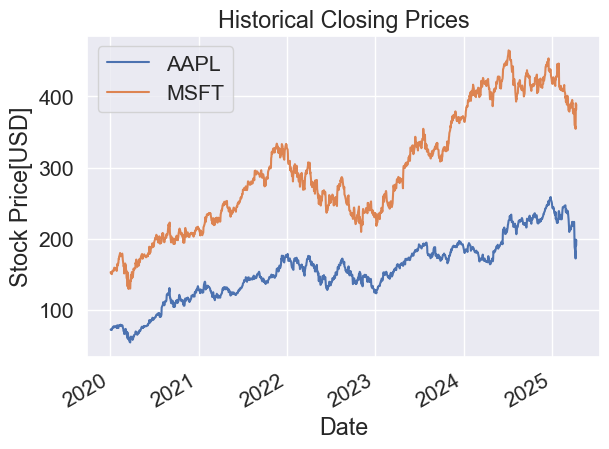

/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(self.data[ticker]['Close'].iloc[-1])
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(self.data[ticker]['Close'].iloc[-1])
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(self.data[ticker]['Close'].iloc[-1])
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:199: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is depre

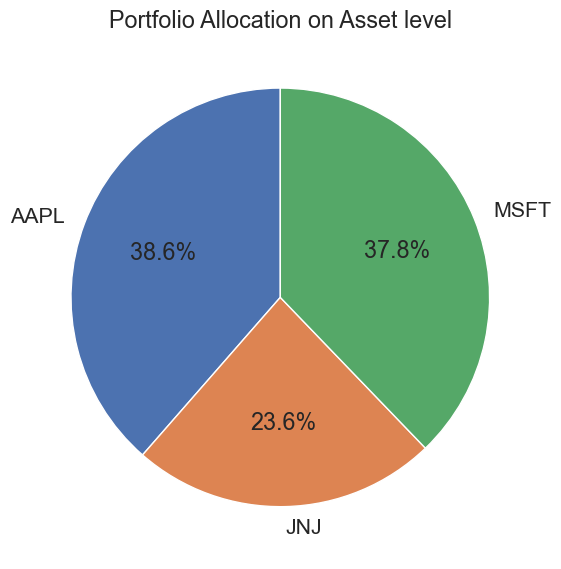

/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(self.data[ticker]['Close'].iloc[-1])
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:170: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = purchase_values[i]
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:171: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inc = incomes[i]
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp

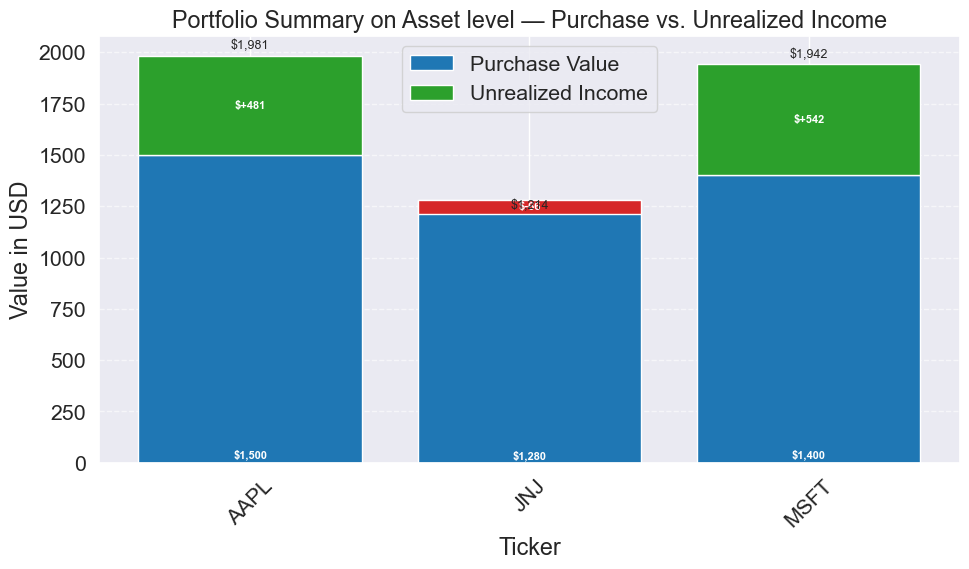

/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:208: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  weekly_var[col]= daily_returns[col].resample('w').apply(lambda x: x.quantile(confidence))
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:208: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  weekly_var[col]= daily_returns[col].resample('w').apply(lambda x: x.quantile(confidence))
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:208: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  weekly_var[col]= daily_returns[col].resample('w').apply(lambda x: x.quantile(confidence))


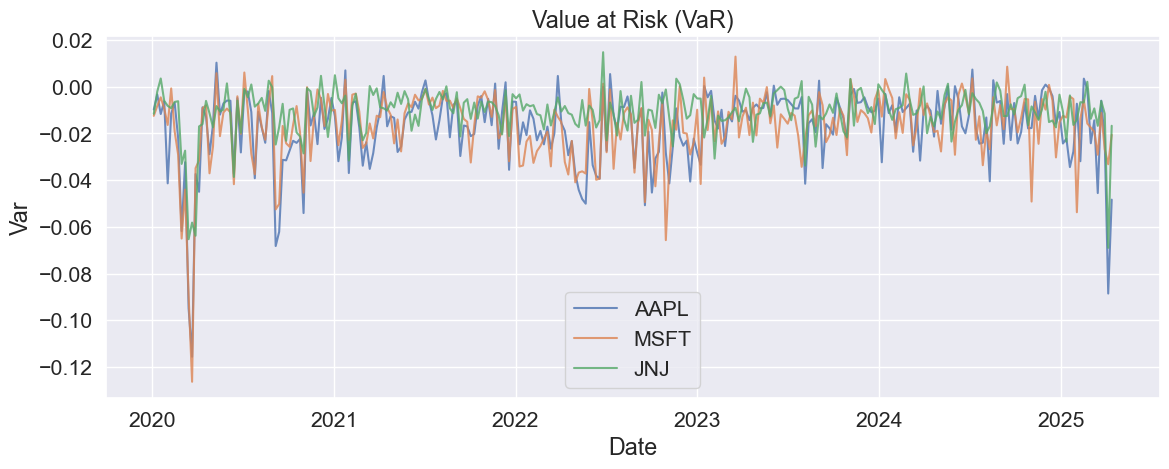

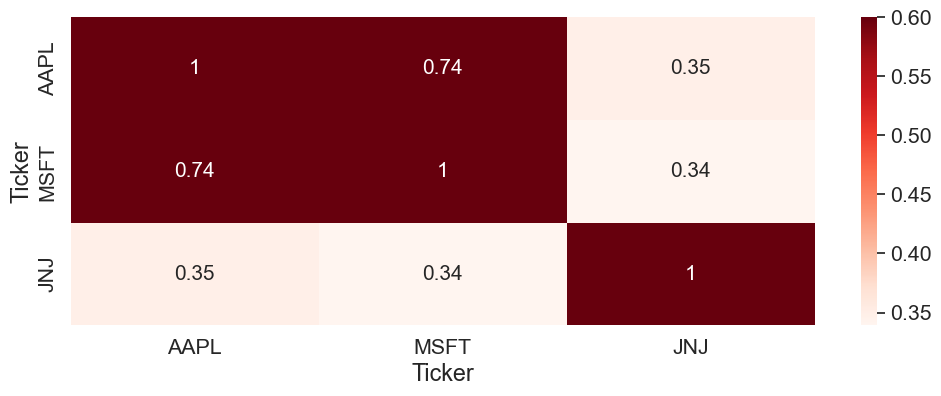

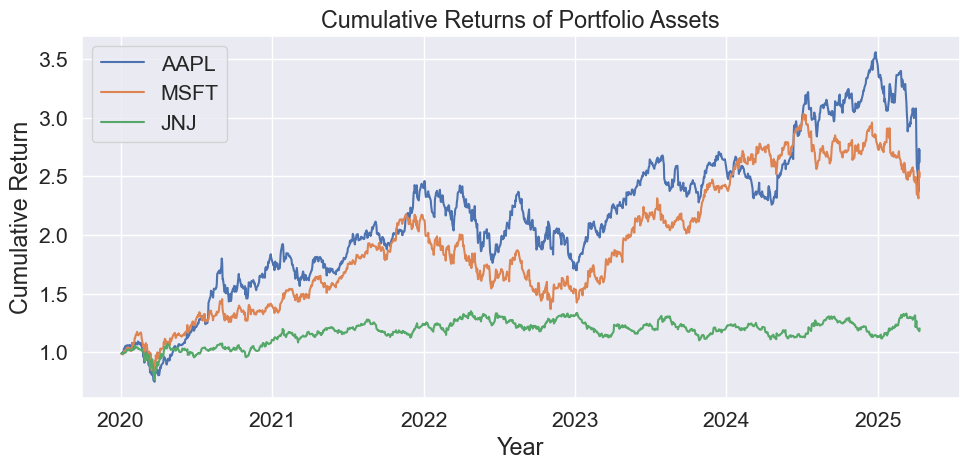

/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(self.data[ticker]['Close'].iloc[-1])
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(self.data[ticker]['Close'].iloc[-1])


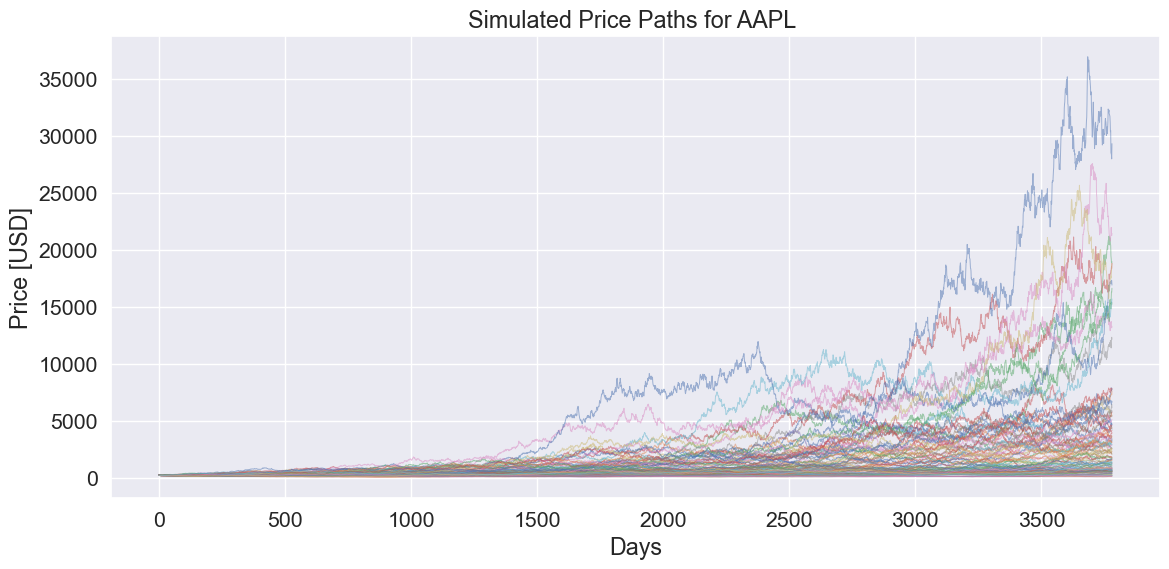

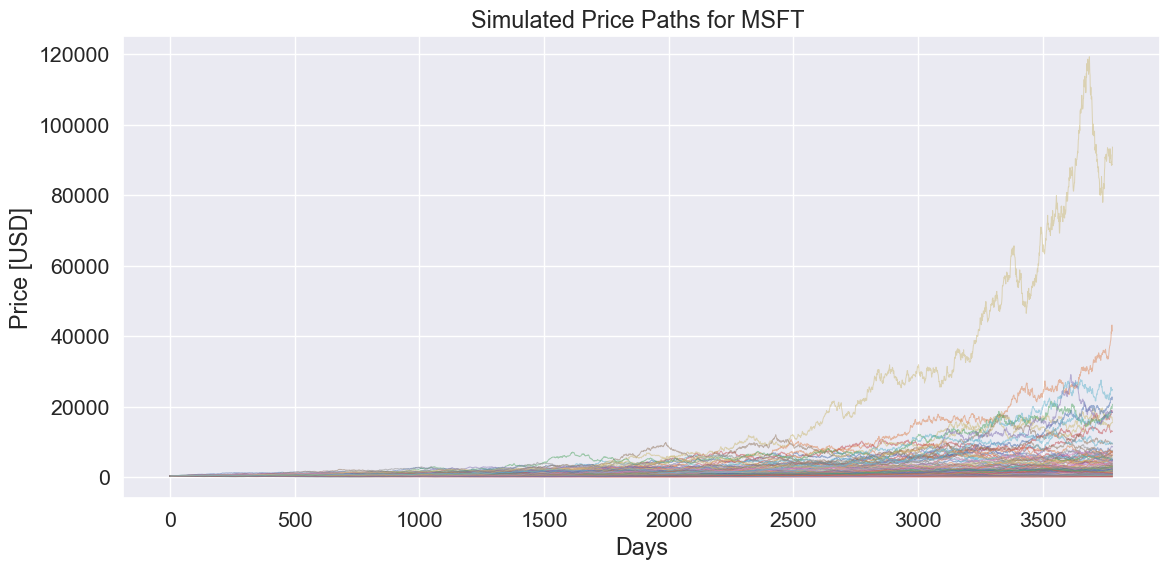

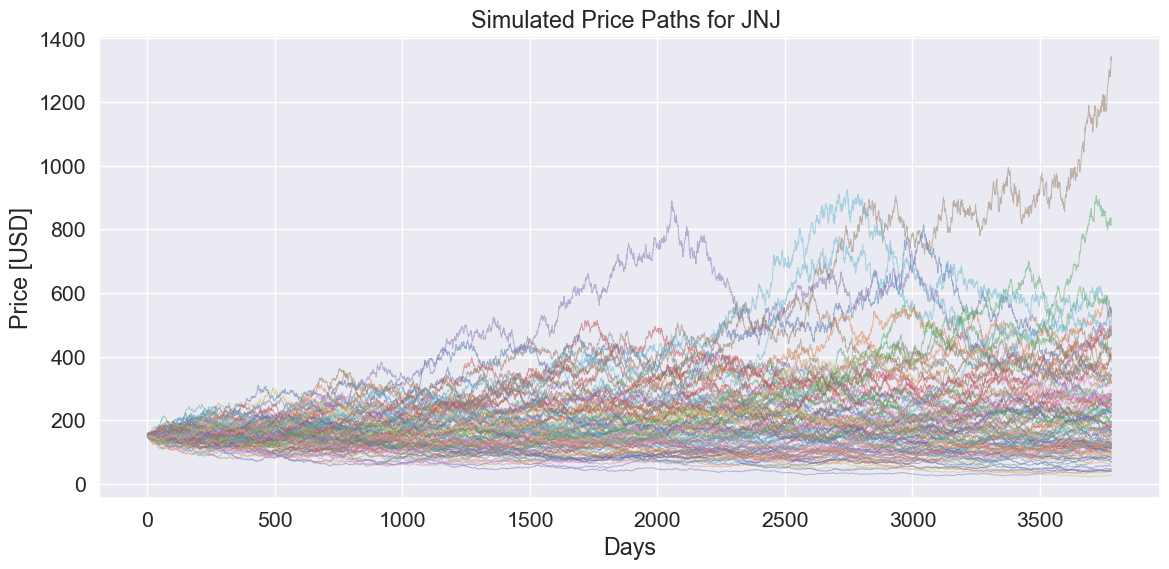

/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(self.data[ticker]['Close'].iloc[-1])
/var/folders/yj/fx1y1b115ngbgq3gmm76hs4c0000gp/T/ipykernel_28517/1621423142.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(self.data[ticker]['Close'].iloc[-1])


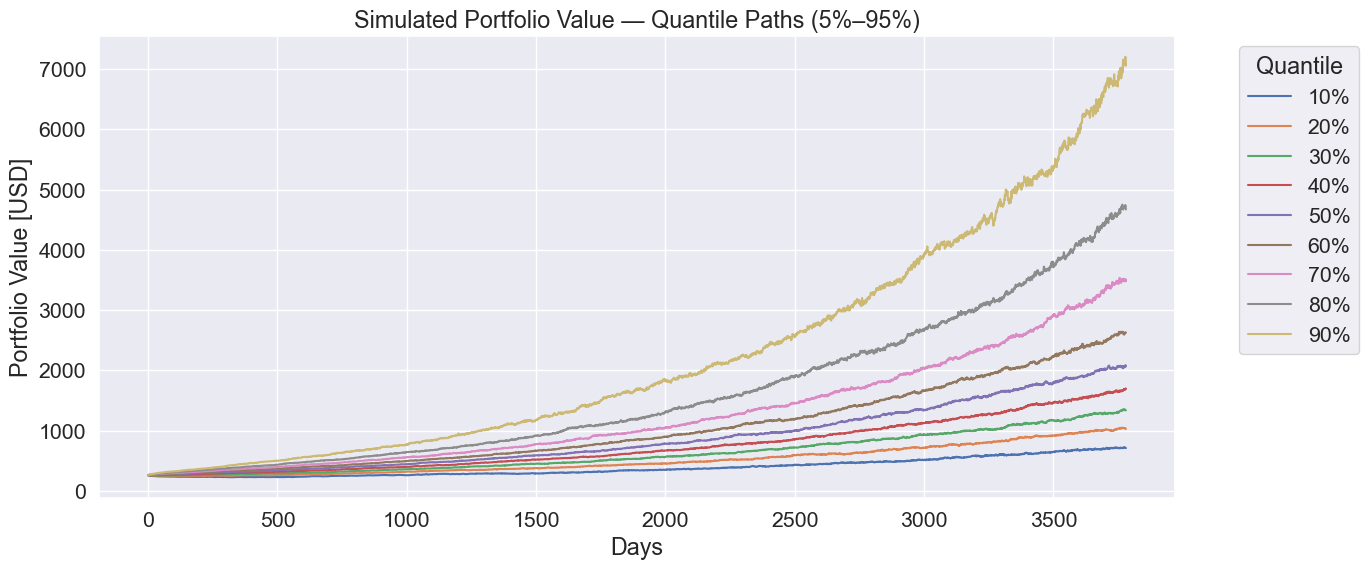

In [653]:
portfolio = ASRPREP()
portfolio.add_stock("AAPL", "Technology", "Equity", 10, 150)
portfolio.add_stock("MSFT", "Technology", "Equity", 5, 280)
portfolio.add_stock("JNJ", "Healthcare", "Equity", 8, 160)
portfolio.download_historical_data_portfolio("2020-01-01")
portfolio.plot_historical_stock_price(["AAPL", "MSFT"],individual_graph=False)
portfolio.current_price("AAPL")
portfolio.portfolio_value()
portfolio.portfolio_weight('asset')
portfolio.portfolio_circle_diagram()
portfolio.portfolio_summary('asset')
portfolio.calculate_plot_var()
portfolio.correlation_plot()
portfolio.cumulative_return()
portfolio.simulate_stock_paths(number_simulations=10)
portfolio.plot_simulated_paths()
portfolio.simulate_portfolio()
portfolio.plot_simulated_portfolio_paths(mode='quantiles')